<a href="https://colab.research.google.com/github/monderei/student-performance-regression/blob/main/UCI_Performance_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
from google.colab import drive
drive.mount('/content/drive')
# figured to put in my github lol

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:

import zipfile
with zipfile.ZipFile("student+performance.zip", "r") as z:
    z.extractall("student_performance")

with zipfile.ZipFile("student_performance/student.zip", "r") as z:
    z.extractall("student_performance")


In [52]:
import pandas as pd
import numpy as np

df = pd.read_csv("student_performance/student-por.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [53]:
df = df.drop(columns=['G1','G2'])

In [54]:
pd.set_option('display.max_columns', None)
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,13


In [55]:
discrepancy = False

for index, value in enumerate(df['school']):
  if value not in ['GP', 'MS'] :
    discrepancy = True
    print(f'discrepancy in school: row {index}')
if not discrepancy:
  print('no discrepancy for school')


for index, value in enumerate(df['sex']):
  if value not in ['M', 'F'] :
    discrepancy = True
    print(f'discrepancy in sex: row {index}')
if not discrepancy:
  print('no discrepancy for sex')

for index, value in enumerate(df['age']):
  if value > 22 or value < 15:
    discrepancy = True
    print(f'discrepancy in age: row {index}')
if not discrepancy:
  print('no discrepancy for age')

for index, value in enumerate(df['Medu']):
  if value > 4 or value < 0:
    discrepancy = True
    print(f'discrepancy in Medu: row {index}')
if not discrepancy:
  print('no discrepancy for Medu')

for index, value in enumerate(df['Fedu']):
  if value > 4 or value < 0:
    discrepancy = True
    print(f'discrepancy in Fedu: row {index}')
if not discrepancy:
  print('no discrepancy for Fedu')





no discrepancy for school
no discrepancy for sex
no discrepancy for age
no discrepancy for Medu
no discrepancy for Fedu


In [56]:
df.address.unique()

array(['U', 'R'], dtype=object)

In [57]:
df.famsize.unique()

array(['GT3', 'LE3'], dtype=object)

In [58]:
df.Pstatus.unique()

array(['A', 'T'], dtype=object)

In [59]:
df.Mjob.unique()


array(['at_home', 'health', 'other', 'services', 'teacher'], dtype=object)

In [60]:
df.Fjob.unique()

array(['teacher', 'other', 'services', 'health', 'at_home'], dtype=object)

In [61]:
df.reason.unique()

array(['course', 'other', 'home', 'reputation'], dtype=object)

In [62]:
df.guardian.unique()

array(['mother', 'father', 'other'], dtype=object)

In [63]:
df.traveltime.unique()


array([2, 1, 3, 4])

In [64]:
df.studytime.unique()

array([2, 3, 1, 4])

In [65]:
df.failures.unique()

array([0, 3, 1, 2])

In [66]:
df.schoolsup.unique()


array(['yes', 'no'], dtype=object)

In [67]:
df.famsup.unique()

array(['no', 'yes'], dtype=object)

In [68]:
df.paid.unique()

array(['no', 'yes'], dtype=object)

In [69]:
df.activities.unique()

array(['no', 'yes'], dtype=object)

In [70]:
df.nursery.unique()

array(['yes', 'no'], dtype=object)

In [71]:
df.higher.unique()

array(['yes', 'no'], dtype=object)

In [72]:
df.internet.unique()

array(['no', 'yes'], dtype=object)

In [73]:
df.romantic.unique()

array(['no', 'yes'], dtype=object)

In [74]:
df.famrel.unique()

array([4, 5, 3, 1, 2])

In [75]:
df.freetime.unique()

array([3, 2, 4, 1, 5])

In [76]:
df.goout.unique()

array([4, 3, 2, 1, 5])

In [77]:
df.Dalc.unique()

array([1, 2, 5, 3, 4])

In [78]:
df.Dalc.unique()

array([1, 2, 5, 3, 4])

In [79]:
df.health.unique()


array([3, 5, 1, 2, 4])

In [80]:
df['absences'].describe()

,absences
count,649.000000
mean,3.659476
std,4.640759
min,0.000000
25%,0.000000
50%,2.000000
75%,6.000000
max,32.000000


In [81]:
from google.colab import userdata
token = userdata.get('githubtoken')

In [82]:
!git clone https://{token}@github.com/monderei/student-performance-regression.git /content/drive/MyDrive/student-performance-regression

fatal: destination path '/content/drive/MyDrive/student-performance-regression' already exists and is not an empty directory.


In [83]:
%cd /content/drive/MyDrive/student-performance-regression

/content/drive/MyDrive/student-performance-regression


In [84]:
!git config user.name "Rayray"
!git config user.email "raymondmarasigan17@gmail.com"

In [85]:
df.head()
binary_features = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

In [86]:
df['school'] = df['school'].replace({'GP' : 0, 'MS' : 1})
df['sex'] = df['sex'].replace({'M': 1 , 'F': 0})
df['address'] = df['address'].replace({'U': 1 , 'R': 0})
df['famsize'] = df['famsize'].replace({'GT3': 1 , 'LE3': 0})
df['Pstatus'] = df['Pstatus'].replace({'T': 1 , 'A': 0})

for feature in binary_features:
  df[feature] = df[feature].replace({'yes': 1, 'no': 0})


/tmp/ipykernel_1196/756489867.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['school'] = df['school'].replace({'GP' : 0, 'MS' : 1})
/tmp/ipykernel_1196/756489867.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'M': 1 , 'F': 0})
/tmp/ipykernel_1196/756489867.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set

In [87]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,0,0,18,1,1,0,4,4,at_home,teacher,course,mother,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,4,11
1,0,0,17,1,1,1,1,1,at_home,other,course,father,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,2,11
2,0,0,15,1,0,1,1,1,at_home,other,other,mother,1,2,0,1,0,0,0,1,1,1,0,4,3,2,2,3,3,6,12
3,0,0,15,1,1,1,4,2,health,services,home,mother,1,3,0,0,1,0,1,1,1,1,1,3,2,2,1,1,5,0,14
4,0,0,16,1,1,1,3,3,other,other,home,father,1,2,0,0,1,0,0,1,1,0,0,4,3,2,1,2,5,0,13


In [88]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['G3'])
y = df['G3']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.4, random_state=42)

X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state=42)

In [89]:
X_train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
404,0,0,17,1,1,1,2,1,services,other,reputation,mother,1,2,0,0,1,0,1,1,1,1,0,4,3,5,2,4,4,4
46,0,0,16,1,0,0,3,3,other,services,home,mother,1,2,0,0,1,0,0,1,1,1,0,2,3,5,1,4,3,6
261,0,0,17,0,1,1,2,1,at_home,services,course,mother,3,2,0,0,0,0,1,1,1,0,0,2,1,1,1,1,3,2
195,0,1,16,1,1,1,3,3,services,other,home,mother,1,2,0,0,0,0,1,1,1,1,1,4,2,3,1,2,3,0
648,1,1,18,0,0,1,3,2,services,other,course,mother,3,1,0,0,0,0,0,0,1,1,0,4,4,1,3,4,5,4


In [90]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


In [91]:
train_ohe = ohe.fit_transform(X_train[['Mjob', 'Fjob', 'reason', 'guardian']])
test_ohe = ohe.transform(X_test[['Mjob', 'Fjob', 'reason', 'guardian']])
valid_ohe = ohe.transform(X_valid[['Mjob', 'Fjob', 'reason', 'guardian']])

ohe_cols = ohe.get_feature_names_out(['Mjob', 'Fjob', 'reason', 'guardian'])

X_train = pd.concat([
	X_train.drop(columns=['Mjob', 'Fjob', 'reason', 'guardian']).reset_index(drop=True), pd.DataFrame(train_ohe, columns=ohe_cols)
], axis=1)

X_test = pd.concat([
	X_test.drop(columns=['Mjob', 'Fjob', 'reason', 'guardian']).reset_index(drop=True), pd.DataFrame(test_ohe, columns=ohe_cols)
], axis=1)

X_valid = pd.concat([
	X_valid.drop(columns=['Mjob', 'Fjob', 'reason', 'guardian']).reset_index(drop=True), pd.DataFrame(valid_ohe, columns=ohe_cols)
], axis=1)

In [92]:
X_train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,0,17,1,1,1,2,1,1,2,0,0,1,0,1,1,1,1,0,4,3,5,2,4,4,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,0,16,1,0,0,3,3,1,2,0,0,1,0,0,1,1,1,0,2,3,5,1,4,3,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0,0,17,0,1,1,2,1,3,2,0,0,0,0,1,1,1,0,0,2,1,1,1,1,3,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,16,1,1,1,3,3,1,2,0,0,0,0,1,1,1,1,1,4,2,3,1,2,3,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1,1,18,0,0,1,3,2,3,1,0,0,0,0,0,0,1,1,0,4,4,1,3,4,5,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [93]:
train_check = X_train.copy()
train_check['G3'] = y_train

correlations = train_check.corr(numeric_only=True)['G3'].sort_values(ascending=False)
print(correlations)

G3                   1.000000
activities           0.129296
freetime             0.114343
Fjob_services        0.086462
absences             0.081699
famsize              0.078556
Mjob_at_home         0.077882
reason_home          0.077305
reason_reputation    0.074926
guardian_father      0.070693
studytime            0.065546
schoolsup            0.058712
Mjob_other           0.058104
famrel               0.047423
address              0.046052
sex                  0.036876
Mjob_teacher         0.032577
Pstatus              0.027690
school               0.020033
romantic             0.015773
Fjob_at_home         0.010739
internet            -0.007205
higher              -0.007784
Fjob_other          -0.016974
guardian_mother     -0.021880
Dalc                -0.024300
traveltime          -0.031169
paid                -0.044665
Walc                -0.049276
Fedu                -0.056340
failures            -0.064105
reason_course       -0.068709
Fjob_health         -0.072399
Mjob_servi

<Axes: >

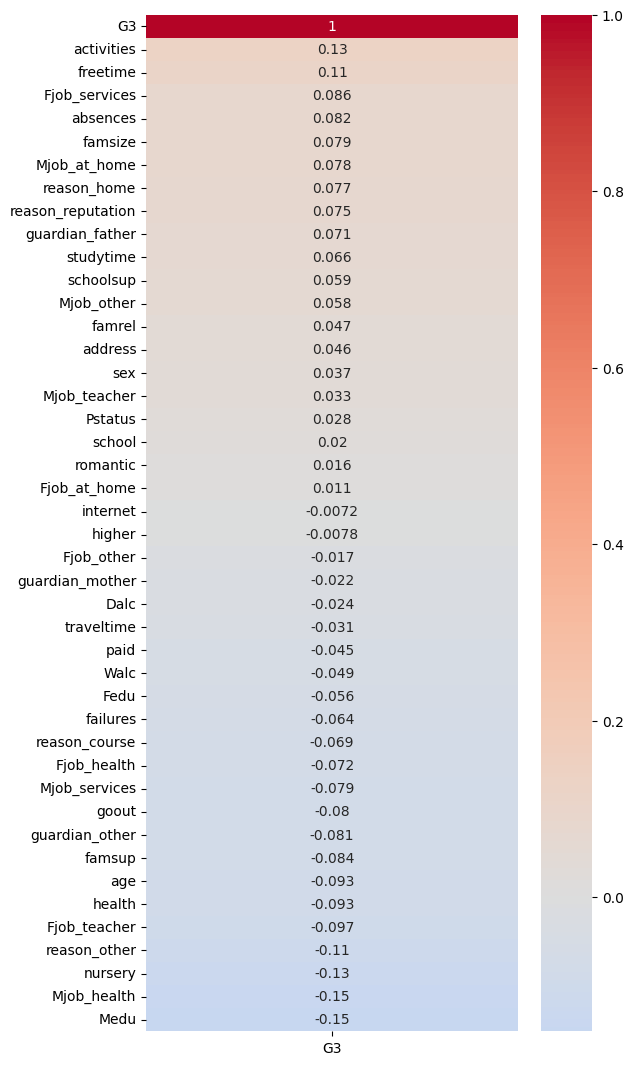

In [94]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.figure(figsize=(6, len(correlations) * 0.3))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', center=0)

In [95]:
import os
print(os.getcwd())

/content/drive/MyDrive/student-performance-regression


In [96]:
X_train.describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
count,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000,389.000000
mean,0.380463,0.408740,16.750643,0.676093,0.719794,0.879177,2.498715,2.282776,1.611825,1.904884,0.239075,0.102828,0.624679,0.059126,0.457584,0.804627,0.897172,0.742931,0.380463,3.889460,3.179949,3.197943,1.516710,2.280206,3.532134,3.768638,0.231362,0.069409,0.403599,0.205656,0.089974,0.069409,0.028278,0.591260,0.277635,0.033419,0.467866,0.221080,0.097686,0.213368,0.215938,0.712082,0.071979
std,0.486126,0.492234,1.266960,0.468568,0.449678,0.326341,1.122921,1.065986,0.783834,0.827181,0.610826,0.304125,0.484829,0.236164,0.498839,0.396998,0.304125,0.437581,0.486126,0.958208,1.064182,1.179462,0.962093,1.314528,1.459812,4.725228,0.422247,0.254475,0.491251,0.404700,0.286513,0.254475,0.165978,0.492234,0.448409,0.179960,0.499609,0.415508,0.297272,0.410213,0.412002,0.453376,0.258787
min,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,16.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,17.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,4.000000,3.000000,2.000000,2.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [97]:
X_train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,0,17,1,1,1,2,1,1,2,0,0,1,0,1,1,1,1,0,4,3,5,2,4,4,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,0,16,1,0,0,3,3,1,2,0,0,1,0,0,1,1,1,0,2,3,5,1,4,3,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0,0,17,0,1,1,2,1,3,2,0,0,0,0,1,1,1,0,0,2,1,1,1,1,3,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,1,16,1,1,1,3,3,1,2,0,0,0,0,1,1,1,1,1,4,2,3,1,2,3,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1,1,18,0,0,1,3,2,3,1,0,0,0,0,0,0,1,1,0,4,4,1,3,4,5,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [98]:
from sklearn.linear_model import LinearRegression

inputs, targets = X_train[['activities', 'freetime', 'Medu', 'Mjob_health', 'nursery', 'reason_other']], y_train


model = LinearRegression().fit(inputs, targets)

validation_set = X_valid[['activities', 'freetime', 'Medu', 'Mjob_health', 'nursery', 'reason_other']]

predictions = model.predict(validation_set)


In [99]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

In [100]:

mse = mean_squared_error(y_valid, predictions)
rmse = np.sqrt(mse)
print(rmse)

3.0957087267140984


In [101]:

mae = mean_absolute_error(y_valid, predictions)
print(mae)

2.287700940156397


In [102]:
y_valid.describe()

,G3
count,130.000000
mean,11.738462
std,3.126664
min,0.000000
25%,10.000000
50%,12.000000
75%,14.000000
max,19.000000


In [103]:
fig = px.histogram(y_valid, x='G3', nbins=20, marginal='box', title='Distribution of col')
fig.show()

In [104]:
zero_grade_mask = (y_valid == 0)
print(f"Number of G3=0 rows in validation: {zero_grade_mask.sum()}")

print("Actual values:     ", y_valid[zero_grade_mask].values)
print("Model's guesses:   ", predictions[zero_grade_mask.values])

Number of G3=0 rows in validation: 3
Actual values:      [0 0 0]
Model's guesses:    [11.04334829  9.41020192 12.80279255]


In [105]:
X_valid[zero_grade_mask.values][['absences', 'failures', 'studytime']]

# The features above give no clear signal that they are affecting why some students get a G3 of 0

,absences,failures,studytime
20,0,0,2
91,0,0,1
123,0,0,2


In [106]:
df_raw = pd.read_csv("student_performance/student-por.csv", sep=';')

zero_grade_indices = y_valid[zero_grade_mask].index
df_raw.loc[zero_grade_indices, ['G1', 'G2', 'G3']]

,G1,G2,G3
440,7,0,0
637,7,7,0
603,5,0,0


The zero y-values in the validation set tipped the root mean squared error by quite a significant amount. Upon further investigation, I have found out that there is no clear relationship with absences, failures, and studytime that affected why the y-value was zero. As seen from the table above, which could be used as a comparison between different grading periods, there was no clear decline in the score, but rather just an instant dip to zero. Moreover, if they were declining, there is a high chance at least one of them would end up with a lower score (around 1-6) but there is no such case.

In [107]:
from sklearn.metrics import r2_score

r2   = r2_score(y_valid, predictions)
mae  = mean_absolute_error(y_valid, predictions)
rmse = root_mean_squared_error(y_valid, predictions)

print(f"R^2: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

R^2: 0.012103696389928031
MAE: 2.287700940156397
RMSE: 3.0957087267140984


In [108]:
# Will try L1
scaler = StandardScaler().set_output(transform='pandas')


X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)



In [109]:
X_train.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,-0.783650,-0.831447,0.197069,0.692161,0.623928,0.370711,-0.444695,-1.204920,-0.781560,0.115136,-0.3919,-0.338546,0.775128,-0.250682,1.088758,0.492759,0.338546,0.588235,-0.783650,0.115510,-0.169313,1.529831,0.502980,1.309983,0.320910,0.049026,-0.548638,-0.273104,-0.822632,1.965324,-0.314436,-0.273104,-0.170589,0.831447,-0.619953,-0.185942,-0.937671,-0.532755,-0.329032,1.920090,-0.524795,0.635871,-0.2785
1,-0.783650,-0.831447,-0.593239,0.692161,-1.602750,-2.697517,0.446987,0.673693,-0.781560,0.115136,-0.3919,-0.338546,0.775128,-0.250682,-0.918478,0.492759,0.338546,0.588235,-0.783650,-1.974409,-0.169313,1.529831,-0.537760,1.309983,-0.364991,0.472831,-0.548638,-0.273104,1.215610,-0.508822,-0.314436,-0.273104,-0.170589,-1.202722,1.613026,-0.185942,-0.937671,1.877034,-0.329032,-0.520809,-0.524795,0.635871,-0.2785
2,-0.783650,-0.831447,0.197069,-1.444750,0.623928,0.370711,-0.444695,-1.204920,1.773287,0.115136,-0.3919,-0.338546,-1.290110,-0.250682,1.088758,0.492759,0.338546,-1.700000,-0.783650,-1.974409,-2.051111,-1.865914,-0.537760,-0.975144,-0.364991,-0.374779,1.822696,-0.273104,-0.822632,-0.508822,-0.314436,-0.273104,-0.170589,-1.202722,1.613026,-0.185942,1.066472,-0.532755,-0.329032,-0.520809,-0.524795,0.635871,-0.2785
3,-0.783650,1.202722,-0.593239,0.692161,0.623928,0.370711,0.446987,0.673693,-0.781560,0.115136,-0.3919,-0.338546,-1.290110,-0.250682,1.088758,0.492759,0.338546,0.588235,1.276079,0.115510,-1.110212,-0.168041,-0.537760,-0.213435,-0.364991,-0.798584,-0.548638,-0.273104,-0.822632,1.965324,-0.314436,-0.273104,-0.170589,0.831447,-0.619953,-0.185942,-0.937671,1.877034,-0.329032,-0.520809,-0.524795,0.635871,-0.2785
4,1.276079,1.202722,0.987377,-1.444750,-1.602750,0.370711,0.446987,-0.265614,1.773287,-1.095346,-0.3919,-0.338546,-1.290110,-0.250682,-0.918478,-2.029389,0.338546,0.588235,-0.783650,0.115510,0.771586,-1.865914,1.543719,1.309983,1.006812,0.049026,-0.548638,-0.273104,-0.822632,1.965324,-0.314436,-0.273104,-0.170589,0.831447,-0.619953,-0.185942,1.066472,-0.532755,-0.329032,-0.520809,-0.524795,0.635871,-0.2785


In [110]:
from sklearn.linear_model import Lasso


lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_features = list(X_train.columns[lasso.coef_ != 0])
print(lasso_features)


['school', 'famsize', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'paid', 'higher', 'internet', 'famrel', 'freetime', 'goout', 'Dalc', 'health', 'absences', 'Mjob_health', 'Mjob_teacher', 'Fjob_services', 'reason_other', 'reason_reputation', 'guardian_other']


In [111]:
lasso_model = LinearRegression().fit(X_train[lasso_features], y_train)

lasso_validation_set = X_valid[lasso_features]

lasso_predictions = lasso_model.predict(lasso_validation_set)

r2   = r2_score(y_valid, lasso_predictions)
mae  = mean_absolute_error(y_valid, lasso_predictions)
rmse = root_mean_squared_error(y_valid, lasso_predictions)

print(f"R^2: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

R^2: 0.19948400689167078
MAE: 1.9768813359679986
RMSE: 2.786694867130988


In [116]:
# Using libraries to potentially make metrics better

from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel

lasso_cv = LassoCV(cv=5).fit(X_train, y_train)
selector = SelectFromModel(lasso_cv, threshold=0.01, prefit=True)
kept_features = X_train.columns[selector.get_support()]
print(kept_features)


Index(['school', 'Fedu', 'studytime', 'failures', 'schoolsup', 'higher',
       'Dalc', 'health', 'Mjob_health', 'Fjob_services', 'reason_other',
       'reason_reputation'],
      dtype='object')


In [117]:
dict(zip(X_train.columns, lasso_cv.coef_))

{'school': np.float64(-0.6236813178114904),
 'sex': np.float64(-0.0),
 'age': np.float64(-0.0),
 'address': np.float64(0.0),
 'famsize': np.float64(-0.0),
 'Pstatus': np.float64(-0.0),
 'Medu': np.float64(0.0),
 'Fedu': np.float64(0.026831914726887236),
 'traveltime': np.float64(-0.0),
 'studytime': np.float64(0.19585023585871528),
 'failures': np.float64(-0.82749947324387),
 'schoolsup': np.float64(-0.3312862782251991),
 'famsup': np.float64(0.0),
 'paid': np.float64(-0.0),
 'activities': np.float64(0.0),
 'nursery': np.float64(-0.0),
 'higher': np.float64(0.3807887103257533),
 'internet': np.float64(0.0),
 'romantic': np.float64(-0.0),
 'famrel': np.float64(0.0),
 'freetime': np.float64(-0.0),
 'goout': np.float64(-0.0),
 'Dalc': np.float64(-0.38472834984791926),
 'Walc': np.float64(-0.0),
 'health': np.float64(-0.07754469213138325),
 'absences': np.float64(-0.0),
 'Mjob_at_home': np.float64(-0.0),
 'Mjob_health': np.float64(0.03028953847616783),
 'Mjob_other': np.float64(0.0),
 'Mjo

In [118]:
print(kept_features)

Index(['school', 'Fedu', 'studytime', 'failures', 'schoolsup', 'higher',
       'Dalc', 'health', 'Mjob_health', 'Fjob_services', 'reason_other',
       'reason_reputation'],
      dtype='object')


In [128]:
lasso_predictions = lasso_cv.predict(X_valid)
r2   = r2_score(y_valid, lasso_predictions)
mae  = mean_absolute_error(y_valid, lasso_predictions)
rmse = root_mean_squared_error(y_valid, lasso_predictions)

print(f"R^2: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

R^2: 0.21506658451059713
MAE: 1.910477668859062
RMSE: 2.7594391406491336


In [129]:

test_predictions = lasso_cv.predict(X_test)

test_r2 = r2_score(y_test, test_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = root_mean_squared_error(y_test, test_predictions)

print(f"Test R^2:  {test_r2:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Test R^2:  0.2214
Test MAE:  2.2181
Test RMSE: 2.9163


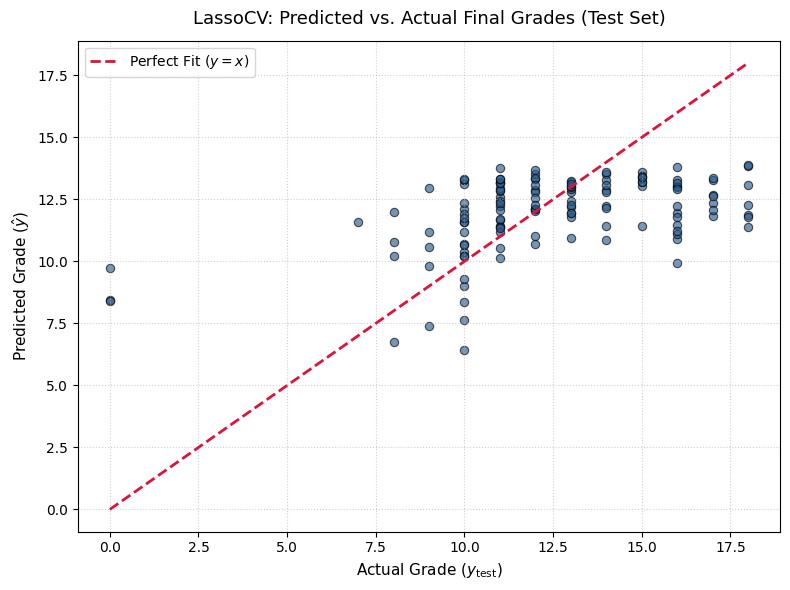

In [130]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, test_predictions, alpha=0.65, edgecolors='black', linewidth=0.8, color="#2b5c8f")


min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label="Perfect Fit ($y = x$)")

plt.title("LassoCV: Predicted vs. Actual Final Grades (Test Set)", fontsize=13, pad=12)
plt.xlabel("Actual Grade ($y_{\\text{test}}$)", fontsize=11)
plt.ylabel("Predicted Grade ($\\hat{y}$)", fontsize=11)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [132]:
train_predictions = lasso_cv.predict(X_train)

print(f"Train R^2:  {r2_score(y_train, train_predictions):.4f}")
print(f"Train MAE:  {mean_absolute_error(y_train, train_predictions):.4f}")
print(f"Train RMSE: {root_mean_squared_error(y_train, train_predictions):.4f}")

Train R^2:  0.3449
Train MAE:  1.9028
Train RMSE: 2.6071
